In [ ]:
pwd

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_curvefit import *

## Preprocess dataFrame

In [ ]:
expt = 'playfight'

In [ ]:
df_data = pd.read_csv(f'../../data/subtlety_playfight_data/{expt}_data.csv',index_col=[0]) 
df_data

In [ ]:
subs = np.unique(df_data['subID'])
print(len(subs))

In [ ]:
chargeSpeeds = np.unique(df_data['chargeSpeeds'])
chargeSpeeds

In [ ]:
df_mean = df_data.groupby(['subID','chargeSpeeds']).mean().reset_index()
df_mean

In [ ]:
len(np.unique(df_mean['subID']))

## Curve-fit

In [ ]:
good_fit = 0.8
nRep = 1000
param_bounds = [(0, 1), (0.0001, 10)]

nsub = len(subs)#350
print('nsub:',nsub)
# params_name = ['subID', 'r_squared', 'nrmse', 'aic',
#                'center', 'sigma', 'bias_lower', 'bias_upper',
#                'center_y', 'obj_center', 'bias_xmin', 'bias_xmax', 'flipped']
params_name = ['subID', 'r_squared', 'nrmse', 'aic',
            'slope', 'intercept','bias_lower', 'bias_upper',
            'obj_center', 'bias_xmin', 'bias_xmax', 'flipped']
df_params = pd.DataFrame(np.zeros((nsub, len(params_name))) * np.nan, columns=params_name)

In [ ]:
# fig_save_loc = pd.read_csv('../data/collected_data/main_data/fig_save_loc.csv',index_col=[0])
# fig_save_loc

In [ ]:
rootfile_data = f'../../data/subtlety_playfight_data/curve_fit_aggressiveness_linear/'
rootfile_data

In [ ]:
rootfile_data

150 30193
flipped 30227
200 30255
250 30320
flipped 30321


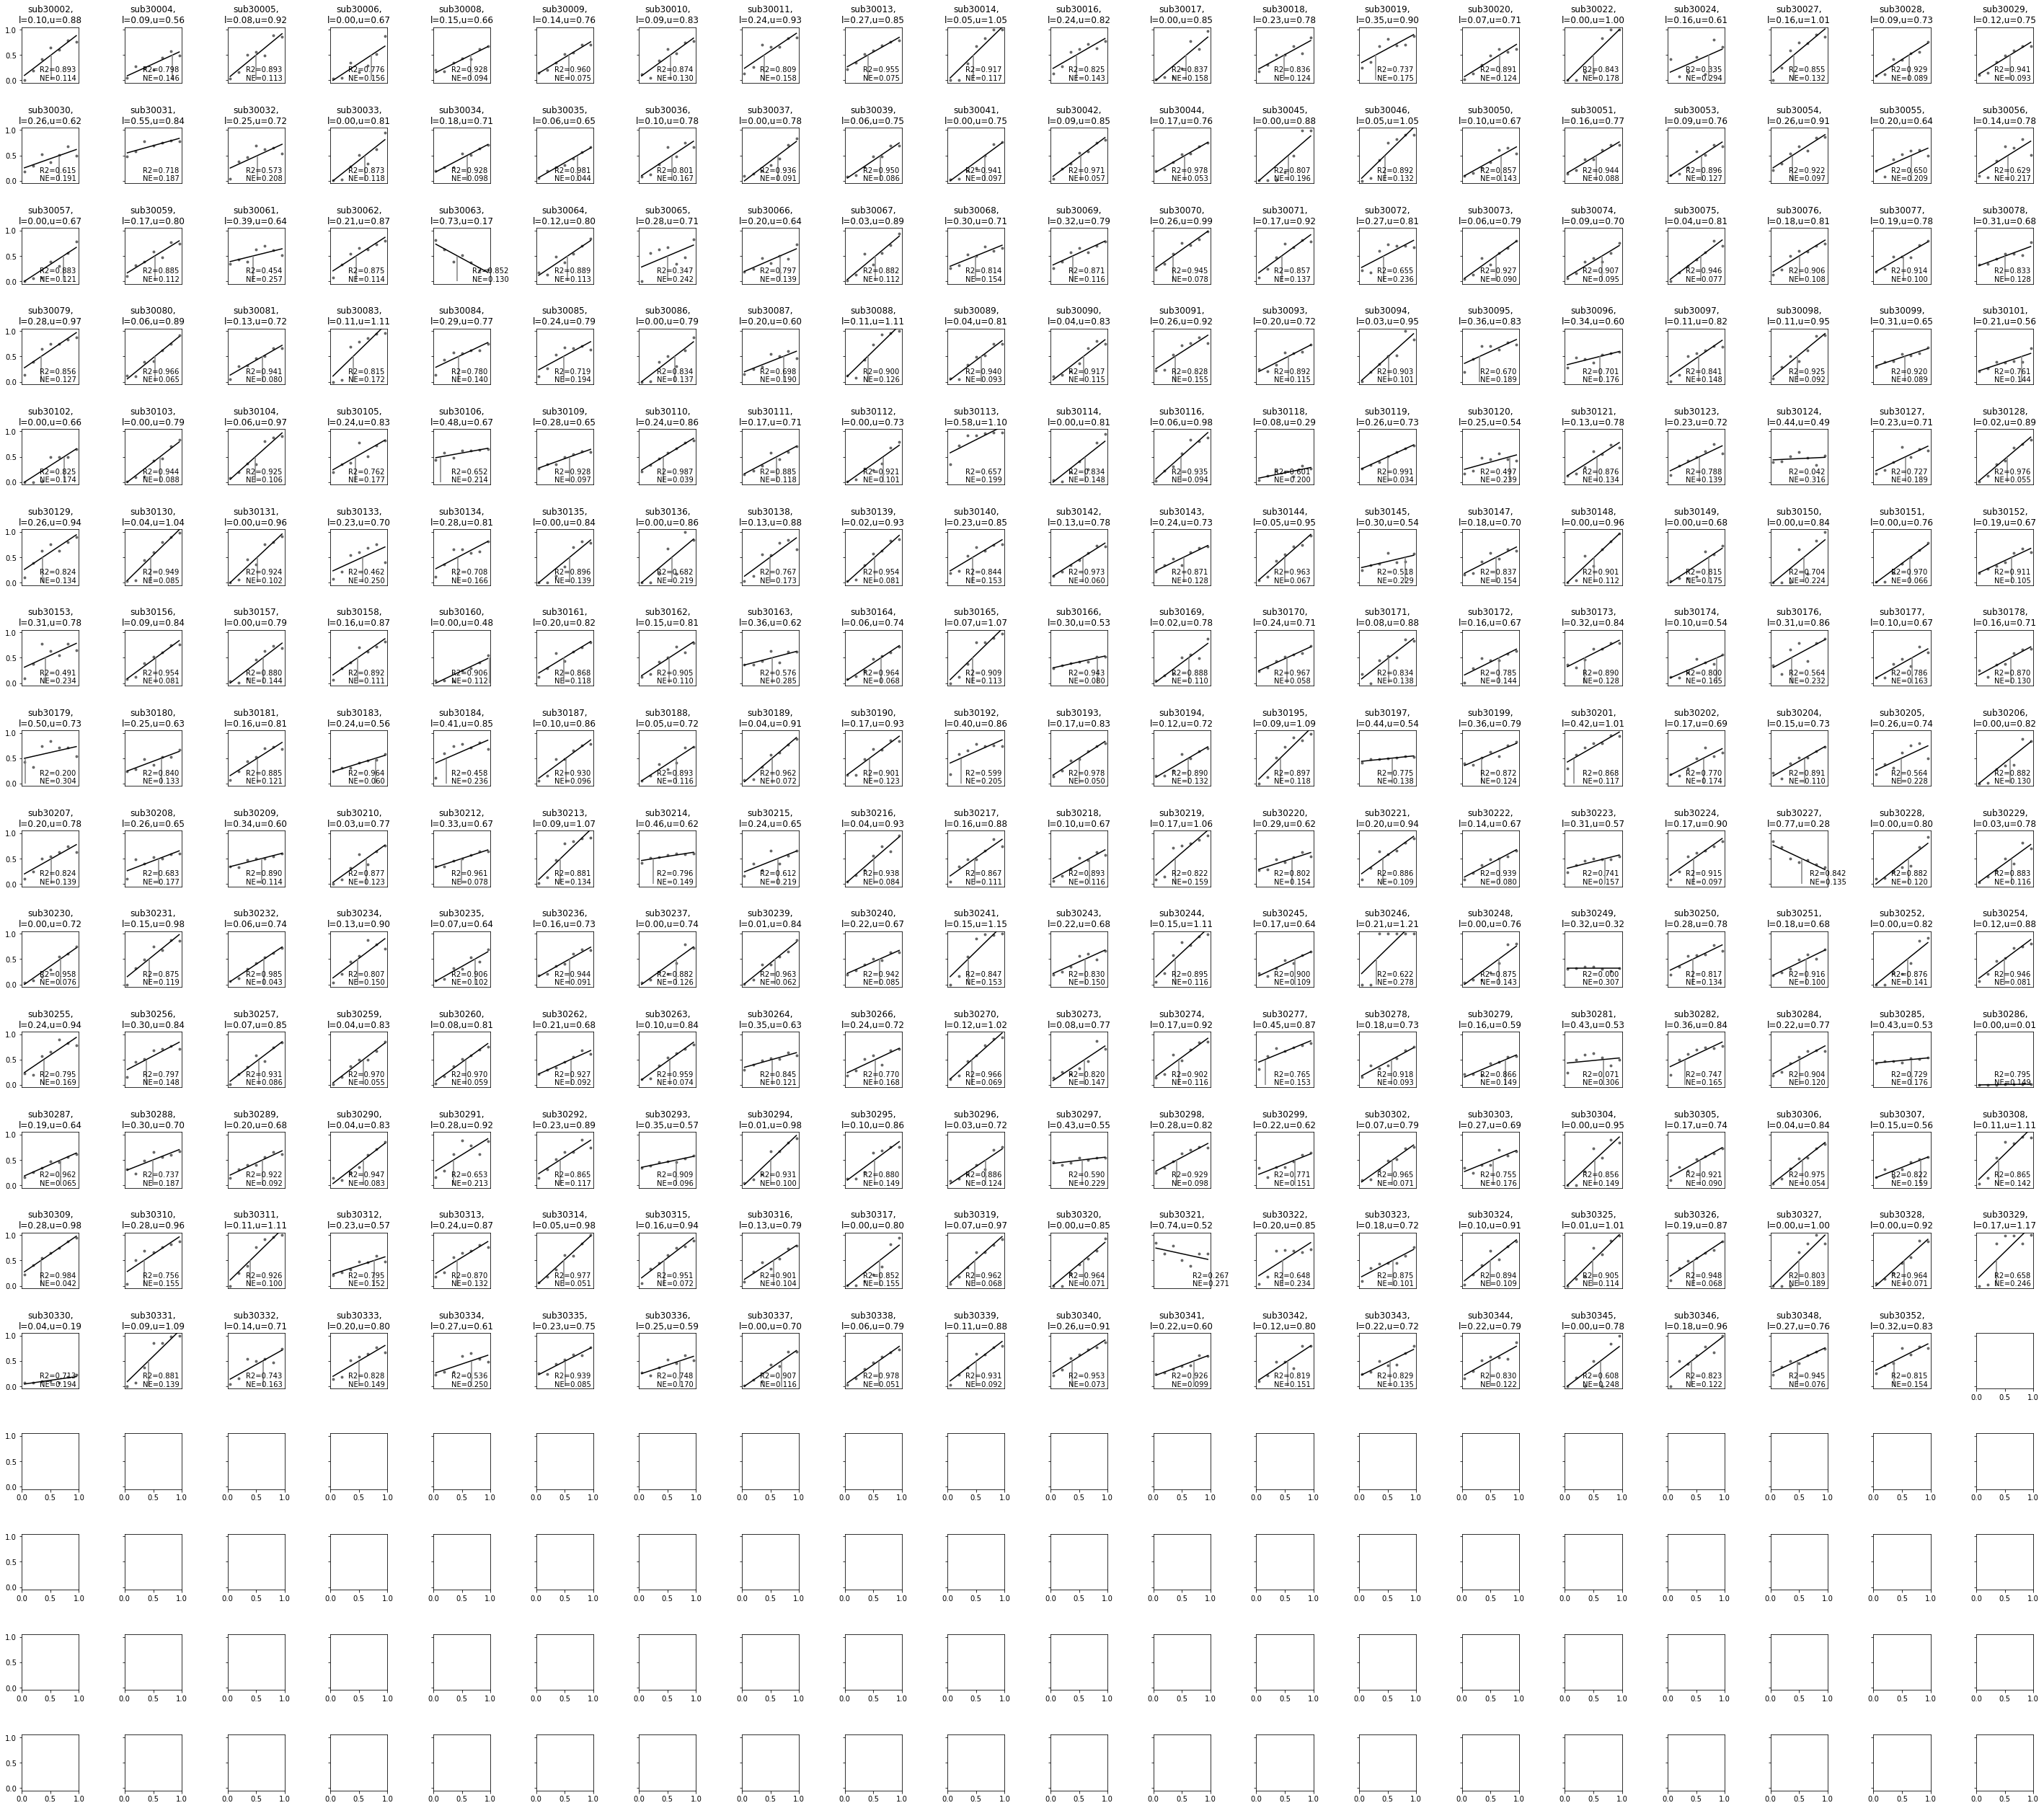

In [19]:
warnings.filterwarnings("ignore")

# nrow, ncol = 35, 10
# fig,axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(20,70))
nrows = 18
ncols = 20
jitter_strength = .01
fig, axs  = plt.subplots(figsize = (50,45), nrows=nrows, ncols = ncols, sharey = True, sharex = False)
best_fit_params = []
subID = []
for isub,subID in enumerate(subs):
    df_params['subID'][isub] = subID #isub + 1
    if isub%50 == 0:
        print(isub, subID)
    ax = plt.subplot(nrows, ncols, isub+1)
    # stim_row = fig_save_loc['subID']==subID
    # r = fig_save_loc.loc[stim_row,'row'].values[0]
    # c = fig_save_loc.loc[stim_row,'column'].values[0]
    # ax = axs[r,c]

    xfit = (df_mean.loc[df_mean['subID'] == subID, 'chargeSpeeds'].values - 1.5)/7.5 # inverse charge speed
    #1-(df_mean.loc[df_mean['subID'] == subID, 'chargeSpeeds'].values - 1.5)/7.5 # inverse charge speed
    yfit = df_mean.loc[df_mean['subID'] == subID,'responses_pf'].values/100 # playfulness

    x = np.array(xfit)
    y = np.array(yfit)

    flipped = False
    if y[x == 0] - y[x == 1] > .001: # flipped subs (curve shape opposite of that expected)
        flipped =  True
        x = np.flip(x)
        print('flipped', subID)

    # try:
    results = fit_linear(x, y, rescale=False, padding=False, n_rep=nRep, param_bounds=param_bounds,
                param_details=f"{rootfile_data}/sub%d_1k_linear.csv"%(subID))
    best_params, goodness_of_fit, other_params = results
    ss_res, df_params['nrmse'][isub], df_params['r_squared'][isub],df_params['aic'][isub] = goodness_of_fit
    
    if flipped == False:
        # df_params['center'][isub], df_params['sigma'][isub], df_params['bias_lower'][isub], df_params['bias_upper'][isub] = best_params
        # df_params['center_y'][isub], df_params['obj_center'][isub], df_params['bias_xmin'][isub], df_params['bias_xmax'][isub] = other_params
        df_params['slope'][isub], df_params['intercept'][isub], df_params['bias_lower'][isub], df_params['bias_upper'][isub] = best_params
        df_params['obj_center'][isub], df_params['bias_xmin'][isub], df_params['bias_xmax'][isub] = other_params
    else: # fightiness decreases with chargespeed (unexpected)
        # print('flipped')
        # df_params['center'][isub], df_params['sigma'][isub], df_params['bias_upper'][isub], df_params['bias_lower'][isub] = best_params
        # df_params['center_y'][isub], df_params['obj_center'][isub], df_params['bias_xmax'][isub], df_params['bias_xmin'][isub] = other_params
        # df_params['bias_upper'][isub] = 1 - df_params['bias_upper'][isub]
        # df_params['bias_lower'][isub] = 1 - df_params['bias_lower'][isub]
        # df_params['bias_xmax'][isub] = 1 - df_params['bias_xmax'][isub]
        # df_params['bias_xmin'][isub] = 1 - df_params['bias_xmin'][isub]
        df_params['slope'][isub], df_params['intercept'][isub], df_params['bias_upper'][isub], df_params['bias_lower'][isub] = best_params
        df_params['obj_center'][isub], df_params['bias_xmax'][isub], df_params['bias_xmin'][isub] = other_params
        df_params['bias_upper'][isub] = 1 - df_params['bias_upper'][isub]
        df_params['bias_lower'][isub] = 1 - df_params['bias_lower'][isub]
        df_params['bias_xmax'][isub] = 1 - df_params['bias_xmax'][isub]
        df_params['bias_xmin'][isub] = 1 - df_params['bias_xmin'][isub]
        df_params['intercept'][isub] = np.nan # the line was fit on flipped x-axis, so this corresponds to the higher end. actual intercept wasn't computed at all for flipped curves

        # e.g. if the curve goes from .8 to .2, bias_xmin should be 0.8. flipped curve will give bias_xmax as 0.2 
        # (on the flipped version of the true curve) which when flipped (i.e., assigned to bias_xmin) and then subtracted from 1 gives us a bias_xmin of 0.8
    
    df_params['flipped'][isub] = flipped

    if np.isnan(df_params['obj_center'][isub]):
        if (df_params['bias_xmin'][isub] >= 0.5) & (df_params['bias_xmax'][isub] <= 0.5):
            obj_center = 0 if flipped == False else 1
        elif (df_params['bias_xmax'][isub] >= 0.5) & (df_params['bias_xmin'][isub] <= 0.5):
            obj_center = 1 if flipped == False else 0
    
    # plot_curve_fit(ax, x, y, best_params, color='black', text_loc=(0.3, 0))
    plot_curve_fit_linear(ax, x, y, best_params, color='black', text_loc=(0.3, 0))

    ax.vlines(df_params['obj_center'][isub],0,.5,color='grey')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    # ax.set_xticks(np.arange(0,1.1,.2))
    if flipped:
        ax.invert_xaxis()
        # df_params['center_y'][isub] = 1-df_params['center_y'][isub] # do this ONLY AFTER plotting
        df_params['obj_center'][isub] = 1-df_params['obj_center'][isub]
    ax.set_title(f"sub{subID},\nl={df_params['bias_xmin'][isub]:.2f},u={1-df_params['bias_xmax'][isub]:.2f}")
    ax.set_xticks([])

    # if isub == 1:
    #     break

plt.subplots_adjust(wspace=0.8, hspace=0.8)
plt.savefig(f'../../results/subtlety_playfight_mixed/linearfit_fight_mixed.png',dpi=300,bbox_inches='tight')

df_params[['subID', 'r_squared', 'nrmse', 'aic', 'obj_center', 'slope', 'intercept', 'bias_xmin', 'bias_xmax', 'bias_lower', 'bias_upper','flipped']].to_csv(f'{rootfile_data}/all_params_1k_fight_mixed_linear.csv', index = False)

In [ ]:
# df_params[['subID', 'r_squared', 'nrmse', 'center', 'obj_center', 'sigma', 'bias_xmin', 'bias_xmax', 'bias_lower', 'bias_upper']].to_csv('../data/curve_fit_rmse/all_params_1k.csv', index = False)
# df_params[['subID', 'r_squared', 'center', 'obj_center', 'sigma', 'bias_xmin', 'bias_xmax']].to_csv('../data/curve_fit_2params_mean/all_params_1k.csv', index = False)

In [ ]:
df_params.sort_values(by=['r_squared']).head()

In [ ]:
df_params.sort_values(by=['r_squared'])

In [ ]:
df_params.loc[df_params['r_squared']<0,:]

In [ ]:
df_corr = df_params[['r_squared','sigma','center','obj_center','bias_xmax','bias_xmin']].corr()
df_corr

In [ ]:
import seaborn as sns

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(df_corr,cmap='RdBu_r',vmin=-1,vmax=1,annot=True)
plt.yticks(rotation = 0)
plt.title('with bad fits too!')

In [ ]:
sns.scatterplot(data = df_params,x = 'sigma', y ='r_squared')

In [ ]:
df_clean = df_params.loc[df_params['r_squared']>=.8,:]
df_clean.shape

In [ ]:
df_clean.loc[np.isinf(df_clean['obj_center']),:]

In [ ]:
obj_center = []
for i,row in df_clean.iterrows():
    if np.isinf(row['obj_center']):
        if np.round(row['bias_xmax'],4) <= .5:
            obj_center.append(1)
        elif np.round(row['bias_xmin'],4) >= .5:
            obj_center.append(0)
    else:
        obj_center.append(row['obj_center'])
df_clean['obj_center'] = obj_center

In [ ]:
df_clean = df_clean.loc[~np.isinf(df_clean['obj_center']),:]
df_clean.shape

In [ ]:
df_corr = df_clean[['r_squared','sigma','center','obj_center','bias_xmax','bias_xmin']].corr()
df_corr

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(df_corr,cmap='RdBu_r',vmin=-1,vmax=1,annot=True)
plt.title(f'Playfight, n={df_clean.shape[0]}')
plt.yticks(rotation = 0)
plt.savefig('../results/covariance_matrix_curvefit.png')

In [ ]:
sns.scatterplot(data = df_clean,x = 'sigma', y ='r_squared')

In [ ]:
plot_curve_param = ['center', 'obj_center', 'sigma', 'bias_xmin', 'bias_xmax', 'r_squared']
df_clean[plot_curve_param].plot(kind='hist', bins=10, subplots=True, sharex=False, sharey=True, layout=(1,len(plot_curve_param)), legend=False, title=plot_curve_param, figsize=(10,1), alpha=0.5)
plt.savefig('../results/curvefit_histograms.png', bbox_inches="tight" )

In [ ]:
from scipy import stats

In [ ]:
sns.scatterplot(data = df_clean, x = 'bias_xmin',y = 'bias_xmax')
plt.gca().set_aspect('equal', adjustable='box')
plt.plot([0,1],[0,1], color ='grey',ls = ':')
plt.xlabel('bias_xmin (bias towards fight)')
plt.ylabel('bias_xmax (bias towards play)')
r,p = stats.pearsonr(df_clean['bias_xmin'], df_clean['bias_xmax'])
print(r,p)
plt.gca().annotate(f'r={r:.2f} (p < .001)',xy = (0.1,.9),xycoords = 'axes fraction')

In [ ]:
for _, row in df_clean.iterrows():
    plt.plot([0.2, .8], [row['bias_xmin'], row['bias_xmax']], '-o', color='grey', alpha = .1)
sns.boxplot(data = df_clean[['bias_xmin','bias_xmax']])

In [ ]:
from scipy import stats

In [ ]:
(df_clean['bias_xmax'] - df_clean['bias_xmin']).mean()

In [ ]:
stats.ttest_rel(df_clean['bias_xmin'],df_clean['bias_xmax'])

In [ ]:
df_clean['center'].describe()

In [ ]:
from pymer4.models import Lmer,Lm
from pymer4.stats import vif

In [ ]:
def vif_info(model):
    design_matrix_df = model.design_matrix
    #design_matrix_df.shape
    # print('model:', model.formula)
    vif_keys= list(vif(design_matrix_df)[1].keys())
    vif_values= list(vif(design_matrix_df)[1].values())
    print('VIF: ',','.join([vif_keys[i] + ': ' + str(np.round(vif_values[i],2)) for i in range(len(vif_keys))]))
    # print('AIC: ', model.AIC)

In [ ]:
model = Lm('subID ~ center + sigma  + bias_xmin  + bias_xmax' , data=df_params) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

In [ ]:
rows = ~np.isnan(df_params['obj_center']) & ~np.isinf(df_params['obj_center'])
model = Lm('subID ~ center + sigma  + bias_xmin  + bias_xmax' , data=df_params.loc[rows,:]) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

In [ ]:
rows = ~np.isnan(df_params['obj_center']) & ~np.isinf(df_params['obj_center'])
model = Lm('subID ~ obj_center + sigma  + bias_xmin  + bias_xmax' , data=df_params.loc[rows,:]) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

In [ ]:
X

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cf_params_1 = ["sigma","center", "bias_xmax", "bias_xmin"]
X = df_params[cf_params_1]
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X.reset_index()
# X.drop(columns=['index'],inplace=True)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

In [ ]:
X.drop(columns=['index'],inplace=True)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

In [ ]:
np.where(np.isnan(X))

In [ ]:
from pymer4.stats import vif
vif(X,has_intercept=False)

In [ ]:
cf_params_1 = ["sigma","obj_center", "bias_xmax", "bias_xmin"]
X = df_params[cf_params_1]
X = X.replace([np.inf, -np.inf], np.nan).dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

In [ ]:
X.columns

In [ ]:
i = X.columns[0]
i

In [ ]:
X.values.shape

In [ ]:
# Assuming X is your design matrix
if isinstance(X, pd.DataFrame):
    features = X.columns
else:
    features = range(X.shape[1])

VIFs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

for feature, vif in zip(features, VIFs):
    print(f"VIF for {feature}: {vif}")


In [ ]:
# from pymer4.stats import vif

# vif(X,has_intercept=False)

In [ ]:

# vif(X,has_intercept=False, exclude_intercept=False)

In [ ]:

# vif(X,has_intercept=False, exclude_intercept=True)